# Titanic Survival Prediction - Machine Learning Project

This notebook walks through a complete machine learning project using the Titanic dataset. We'll predict whether passengers survived the Titanic disaster based on their characteristics.

## Step 1: Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Set style for plots
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')


## Step 2: Load and Explore the Data
Let's load our dataset and take an initial look at it.

In [3]:
# load the dataset
titanic_data = pd.read_csv("titanic.csv")

In [4]:
# display first five rows.
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# display last five rows.
titanic_data.tail()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [6]:
# Basic information of data.
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [7]:
# satatistical summary of numerical columns.
titanic_data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observations from initial exploration:
- We have 891 entries (passengers)
- Some columns have missing values (Age, Cabin, Embarked)
- Columns include:
  - PassengerId: Unique ID for each passenger
  - Survived: Target variable (0 = No, 1 = Yes)
  - Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
  - Name, Sex, Age
  - SibSp: # of siblings/spouses aboard
  - Parch: # of parents/children aboard
  - Ticket: Ticket number
  - Fare: Passenger fare
  - Cabin: Cabin number
  - Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

## Step 3: Data Visualization
Visualizing data helps us understand patterns and relationships.

<Axes: xlabel='survived', ylabel='count'>

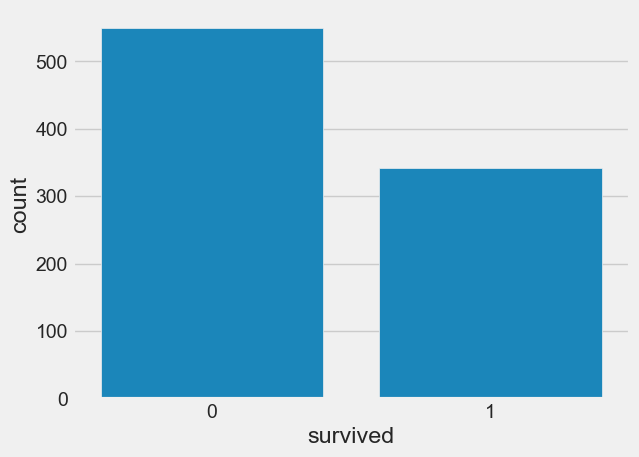

In [8]:
# survival count.
sns.countplot(x = "survived", data=titanic_data) 

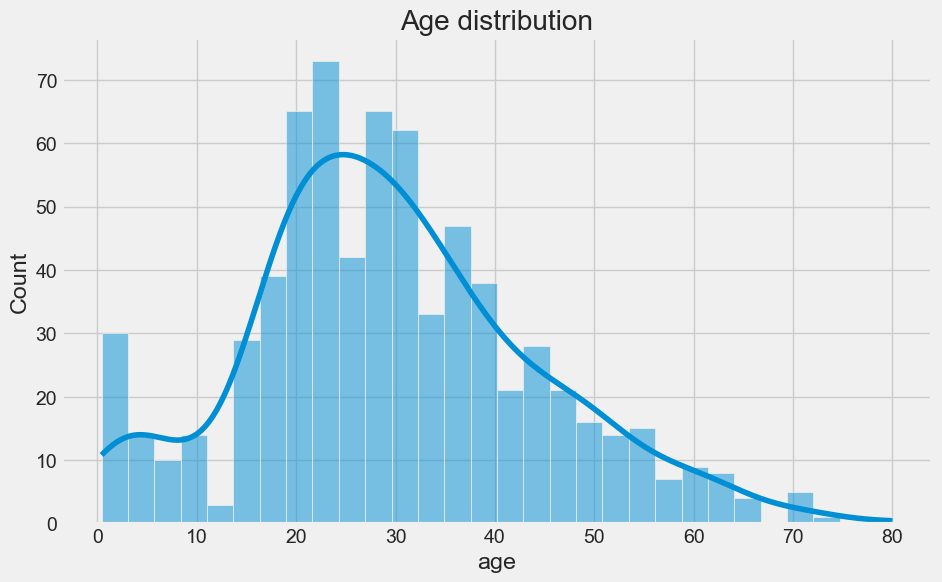

In [9]:
# age distribution.
plt.figure(figsize=(10,6))
sns.histplot(titanic_data["age"].dropna(), kde=True, bins=30)
plt.title("Age distribution")
plt.show()

### Findings from visualizations:
- More passengers died than survived
- Females had much higher survival rates
- Higher class passengers (1st class) had better survival rates
- Most passengers were between 20-40 years old

## Step 4: Data Cleaning and Preprocessing
Real-world data is often messy. Let's clean it up!

In [10]:
# check missing values.
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
# For embarked, only two values are missing. fill them with most common value(mode)
titanic_data["embarked"] = titanic_data["embarked"].fillna(titanic_data['embarked'].mode()[0])

In [12]:
# For age: fill missing values with median age.
titanic_data['age'] = titanic_data['age'].fillna(titanic_data['age'].median())

In [13]:
# check missing values.
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
titanic_data.drop(['class','who','deck','alive','alone','adult_male','embark_town'],axis=1, inplace=True)

In [15]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [16]:
titanic_data.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

 ## Step 5: Feature Engineering. Encode Categorical Variables
Machine learning models work with numbers, not text, so we need to convert categorical variables.

In [17]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [18]:
# Convert categorical variables to numerical
Label_Encoder = LabelEncoder()
catgorical_columns = ['sex' , 'embarked']
for column in catgorical_columns:
    titanic_data[column] = LabelEncoder().fit_transform(titanic_data[column])
    
    
# Show transformed data
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## Step 7: Prepare Data for Modeling
Split our data into features (X) and target (y), then into training and test sets.

In [19]:
# seperate features and target variable
X = titanic_data.drop('survived', axis=1)
y = titanic_data['survived']


# Split dataset into training and testing sets.
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,random_state=42)


In [20]:
# Show the shape of training and testing data.
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (712, 7)
Testing data shape: (179, 7)


## Step 8: Train a Machine Learning Model
We'll use a Random Forest classifier, which works well for this type of problem.


In [21]:
# initializing the model.
model = RandomForestClassifier(n_estimators=100, random_state=42)

# fitting the model.
model.fit(X_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Step 9: Evaluate the Model
Let's see how well our model performs.

In [22]:
# Make predictions on the test set.
y_pred = model.predict(X_test)
# Evaluate the model.
accuracy = accuracy_score(y_test,y_pred)
print(f"Model Accuracy : {accuracy:.2f}")

Model Accuracy : 0.82


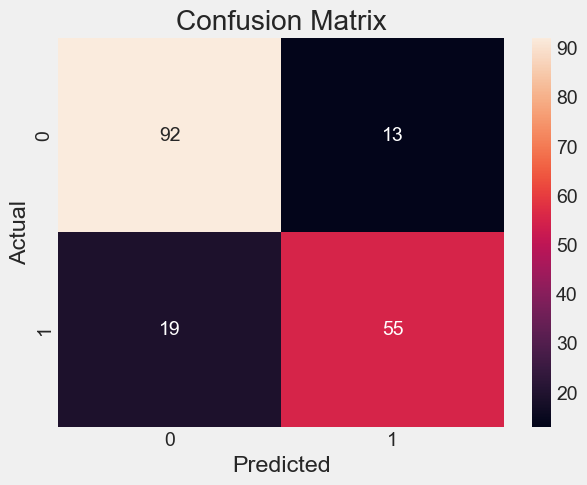

In [23]:
# confusion matrix.
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt ='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [24]:
# Classification report.
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## Step 10: Feature Importance
Let's see which features were most important for predictions.

In [26]:
# Get features importance.
feature_imp = pd.DataFrame(
                        {'Feature': X.columns, 'Importance': model.feature_importances_
                        },).sort_values('Importance', ascending=False)

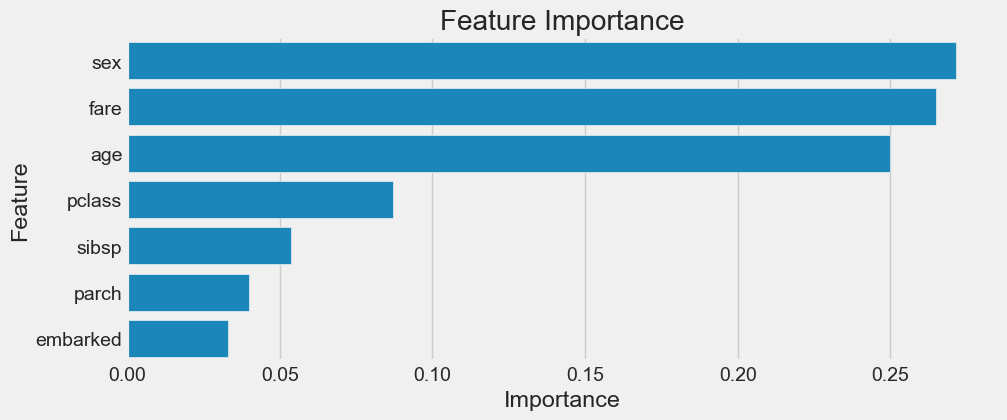

In [31]:
# Plotting the features importance.
plt.figure(figsize=(10,4))
sns.barplot(x='Importance', y='Feature', data=feature_imp)
plt.title('Feature Importance')
plt.show()

## Step 11: Make Predictions on New Data
Now let's use our trained model to predict survival for new passengers.

In [32]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [43]:
# create a new sample passenger data
new_pasenger = pd.DataFrame({
    'pclass':[2],
    'sex':[1],
    'age':[60],
    'sibsp':[1],
    'parch':[0],
    'fare':[25.25],
    'embarked':[0] 
})

# scale numerical features.
new_pasenger[['age','fare']] = StandardScaler().fit_transform(new_pasenger[['age','fare']])

# make prediction for new passenger.
new_prediction = model.predict(new_pasenger)

print(f"New Passenger Survival Prediction: {'Survived' if new_prediction[0] == 1 else 'Did not survive'}")


New Passenger Survival Prediction: Survived


## Conclusion

In this project, we:
1. Explored and visualized the Titanic dataset
2. Cleaned and preprocessed the data
3. Created new features through feature engineering
4. Trained a Random Forest classifier
5. Evaluated the model's performance
6. Made predictions on new data

Our model achieved about 82% accuracy, which is decent for a first attempt. There are many ways to improve this:
- Try different machine learning algorithms
- Perform more feature engineering
- Tune the model's hyperparameters
- Use more advanced techniques like cross-validation